In [1]:
!pip install pandas matplotlib seaborn plotly  fredapi
!pip install lime
import lightgbm as lgb
import matplotlib.pyplot as plt
import pandas as pd
from fredapi import Fred
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import shap
import lime
import lime.lime_tabular
!pip install PyALE
import matplotlib.pyplot as plt
import pandas as pd
import random
from PyALE import ale

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=9eb9c91cc109bb333dbf16fb87625eb22e850806f3b491c29ac6f7d8c3135737
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [2]:
fred = Fred(api_key='e956a3dbccd7d4f90be734f8d55b1d07')

# Features and Target
series_ids = {
    'RSAFS': 'Retail Sales: All Food Services (Target)',
    'CPIAUCSL': 'Consumer Price Index',
    'UNRATE': 'Unemployment Rate',
    'FEDFUNDS': 'Federal Funds Rate',
    'PCE': 'Personal Consumption Expenditures',
    'DSPIC96': 'Real Disposable Personal Income'
}

# Data from FRED
data = pd.DataFrame()
for series_id in series_ids:
    data[series_id] = fred.get_series(series_id)

data.index = fred.get_series('RSAFS').index

data.dropna(inplace=True)

data.rename(columns=series_ids, inplace=True)

data.reset_index(inplace=True)
data.rename(columns={'index': 'ds', 'Retail Sales: All Food Services (Target)': 'y'}, inplace=True)

In [3]:
def detect_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)][column]
    return outliers

In [4]:
print("Outlier Detection Results (Before Model Training):")
for feature in data.columns:
    outliers = detect_outliers(data, feature)
    print(f"\nOutliers in {feature}: {len(outliers)} outliers found")
    if not outliers.empty:
        print(outliers.head())

Outlier Detection Results (Before Model Training):

Outliers in ds: 0 outliers found

Outliers in y: 0 outliers found

Outliers in Consumer Price Index: 0 outliers found

Outliers in Unemployment Rate: 9 outliers found
213    10.0
214     9.9
215     9.9
218     9.9
219     9.9
Name: Unemployment Rate, dtype: float64

Outliers in Federal Funds Rate: 0 outliers found

Outliers in Personal Consumption Expenditures: 0 outliers found

Outliers in Real Disposable Personal Income: 0 outliers found


In [5]:
data.head()

,ds,y,Consumer Price Index,Unemployment Rate,Federal Funds Rate,Personal Consumption Expenditures,Real Disposable Personal Income
0,1992-01-01,159177.0,138.3,7.3,4.03,4084.7,7474.8
1,1992-02-01,159189.0,138.6,7.4,4.06,4099.5,7507.2
2,1992-03-01,158647.0,139.1,7.4,3.98,4117.0,7513.8
3,1992-04-01,159921.0,139.4,7.4,3.73,4131.5,7535.0
4,1992-05-01,160471.0,139.7,7.6,3.82,4158.4,7570.2


In [6]:
print(data.isnull().sum())

ds                                   0
y                                    0
Consumer Price Index                 0
Unemployment Rate                    0
Federal Funds Rate                   0
Personal Consumption Expenditures    0
Real Disposable Personal Income      0
dtype: int64


In [7]:
print(data.describe())

                                  ds              y  Consumer Price Index  \
count                            399     399.000000            399.000000   
mean   2008-07-31 18:02:42.406014976  373811.568922            212.337426   
min              1992-01-01 00:00:00  158647.000000            138.300000   
25%              2000-04-16 00:00:00  265839.000000            171.100000   
50%              2008-08-01 00:00:00  351916.000000            213.022000   
75%              2016-11-16 00:00:00  453869.500000            242.331500   
max              2025-03-01 00:00:00  722025.000000            319.775000   
std                              NaN  146578.635032             47.456756   

       Unemployment Rate  Federal Funds Rate  \
count         399.000000          399.000000   
mean            5.671429            2.608622   
min             3.400000            0.050000   
25%             4.300000            0.190000   
50%             5.300000            2.190000   
75%             6.

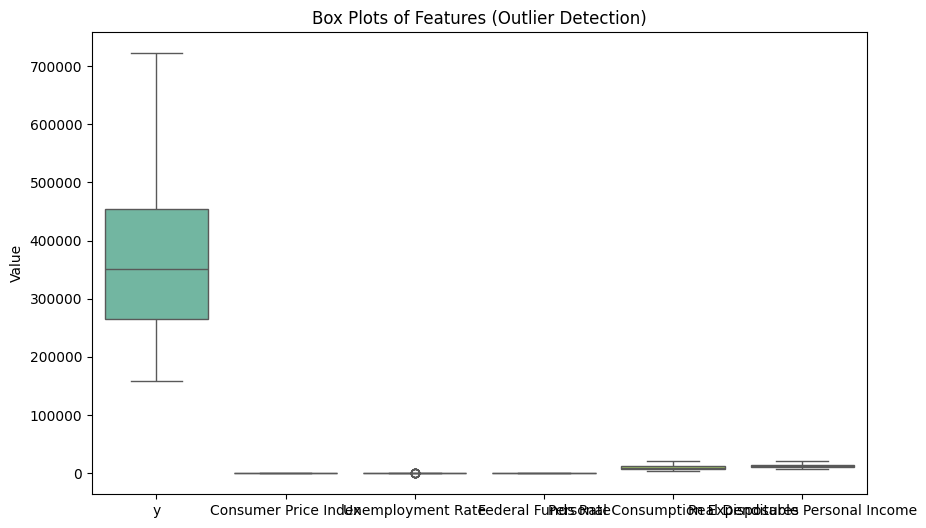

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, palette='Set2')
plt.title('Box Plots of Features (Outlier Detection)')
plt.ylabel('Value')
plt.savefig('feature_boxplots.png')


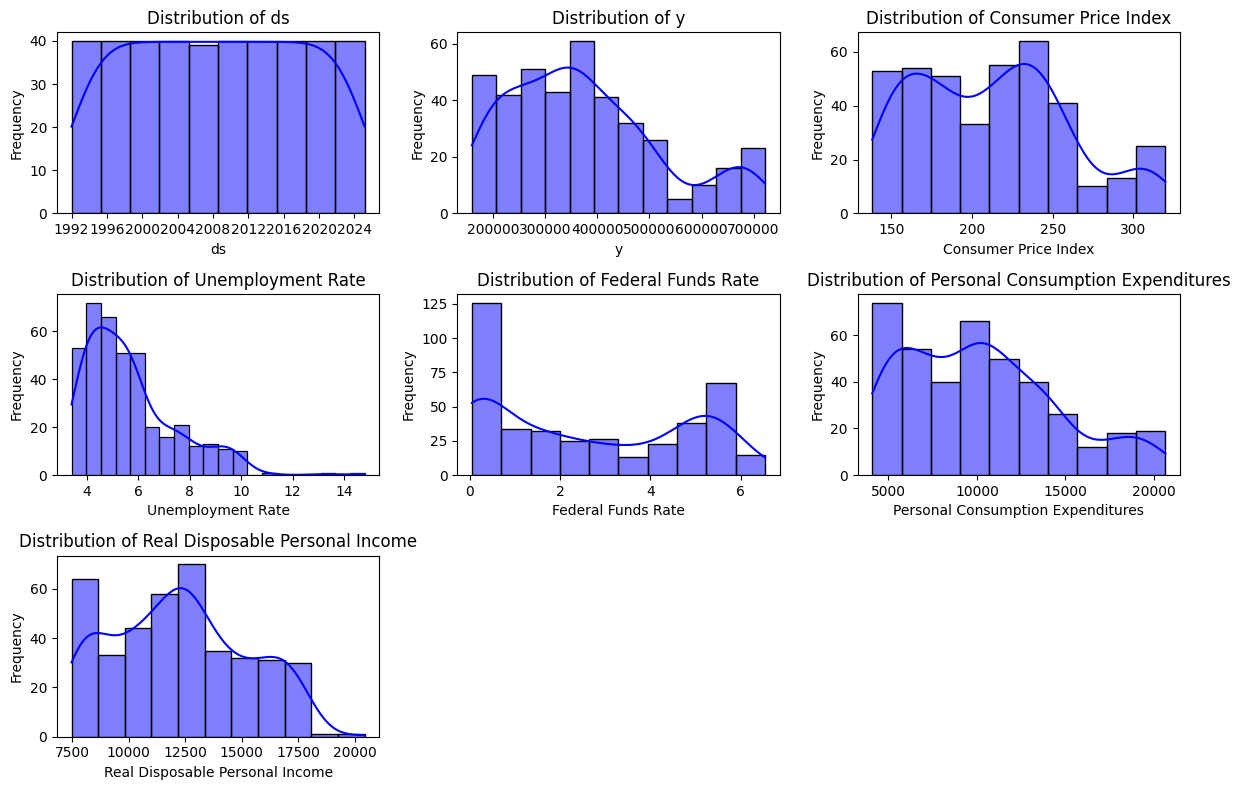

In [9]:
plt.figure(figsize=(12, 8))
num_cols = len(data.columns)
num_rows = (num_cols + 2) // 3

for i, feature in enumerate(data.columns, 1):
    plt.subplot(num_rows, 3, i)
    sns.histplot(data[feature], kde=True, color='blue')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('feature_histograms.png')

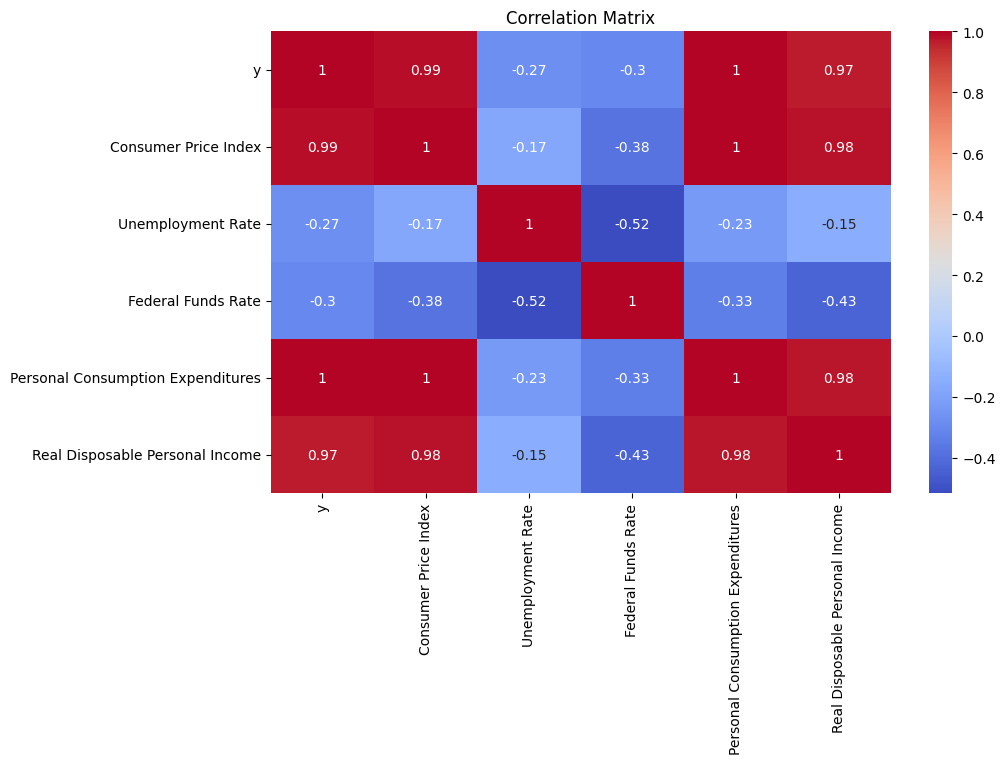

In [10]:
correlation = data.drop(columns=['ds']).corr()

plt.figure(figsize=(10,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

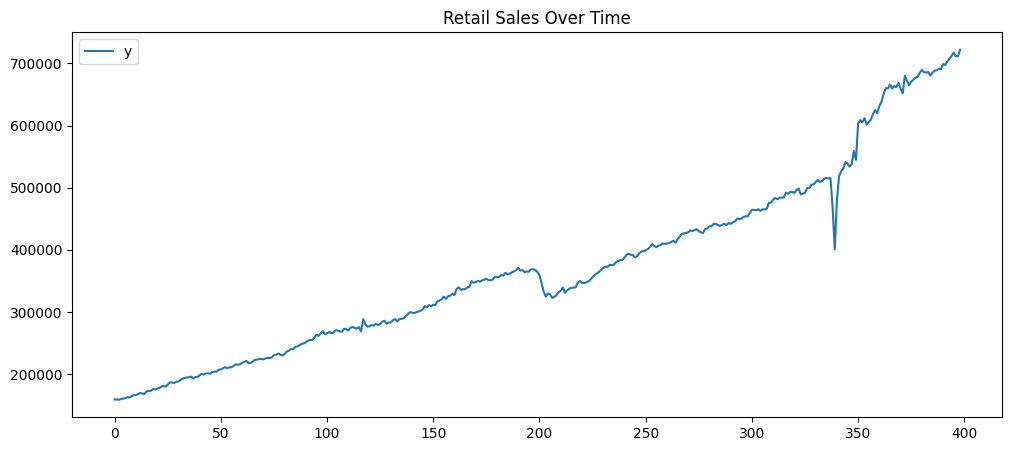

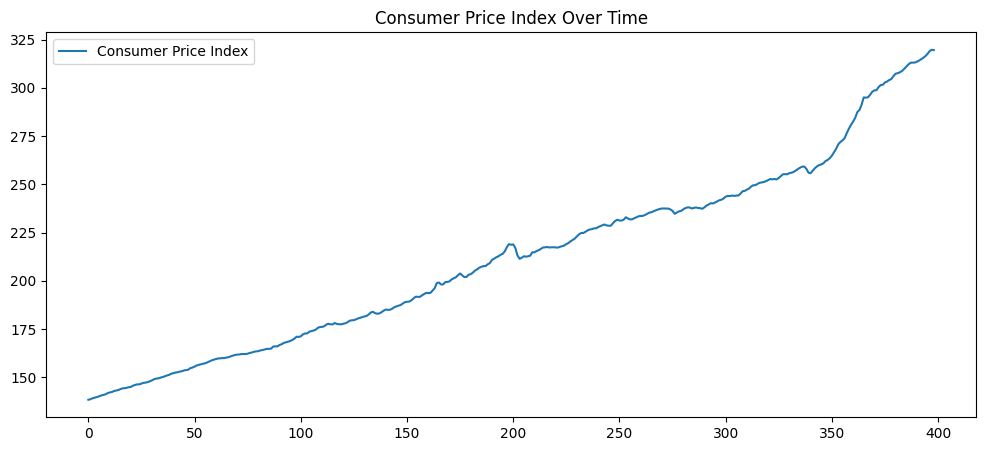

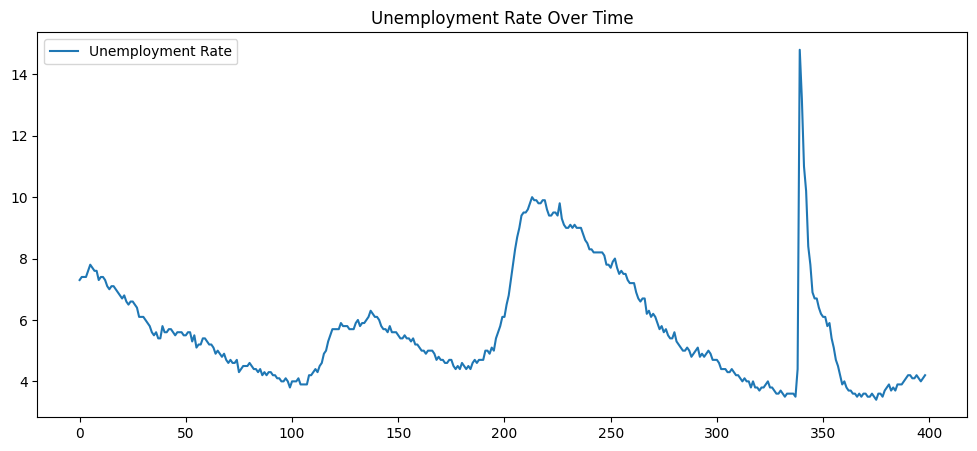

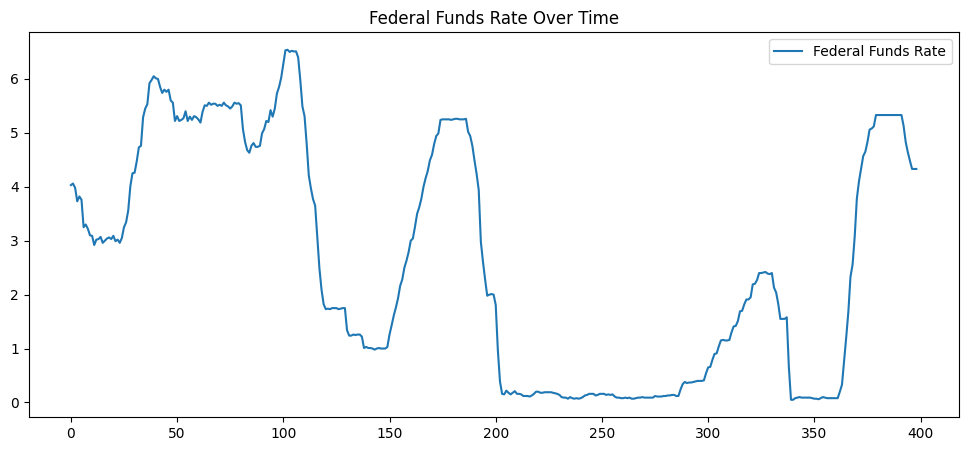

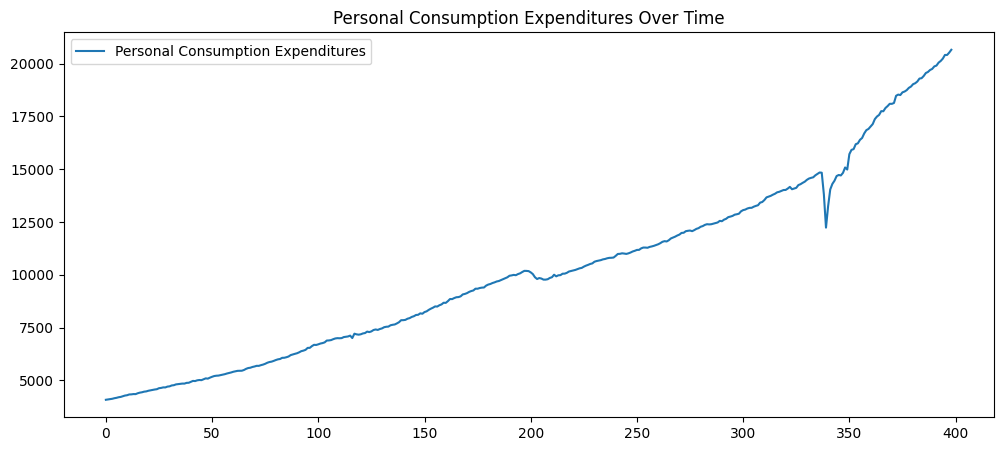

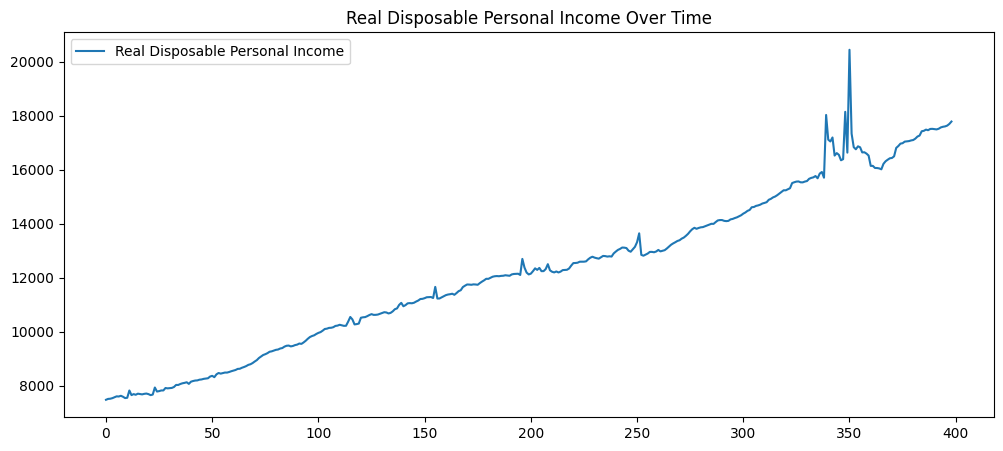

In [11]:
features = ['Consumer Price Index', 'Unemployment Rate', 'Federal Funds Rate', 'Personal Consumption Expenditures', 'Real Disposable Personal Income']


data[['y']].plot(figsize=(12,5), title="Retail Sales Over Time")
plt.show()

for feature in features:
    data[[feature]].plot(figsize=(12,5), title=f'{feature} Over Time')
    plt.show()

In [12]:
X = data[['y', 'Consumer Price Index', 'Unemployment Rate', 'Federal Funds Rate', 'Personal Consumption Expenditures', 'Real Disposable Personal Income']]
y = data['Unemployment Rate']

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [14]:
print(X_train.shape, X_test.shape)

(319, 6) (80, 6)


In [15]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1, max_depth=10, min_samples_split=10)
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_split=10, n_estimators=50,
                      n_jobs=-1, random_state=42)

In [16]:
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # Import r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 0.52
R-squared (R2): 0.88


INFO:PyALE._ALE_generic:Continuous feature detected.


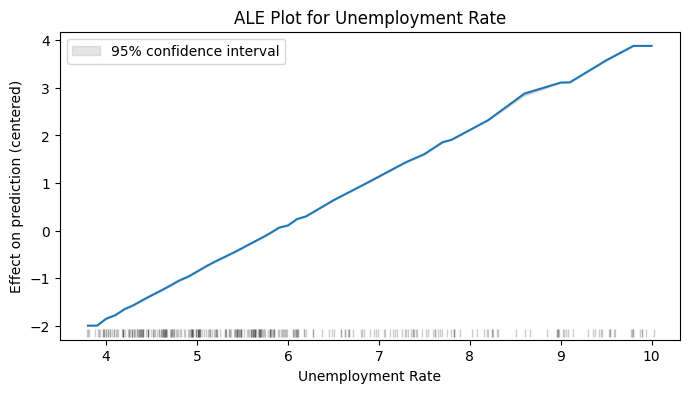

INFO:PyALE._ALE_generic:Continuous feature detected.


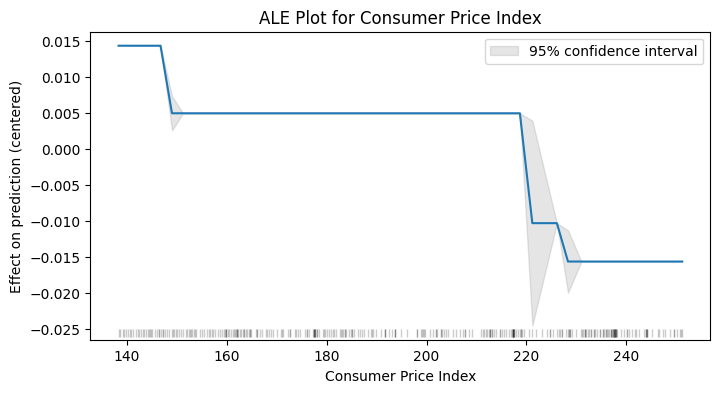

INFO:PyALE._ALE_generic:Continuous feature detected.


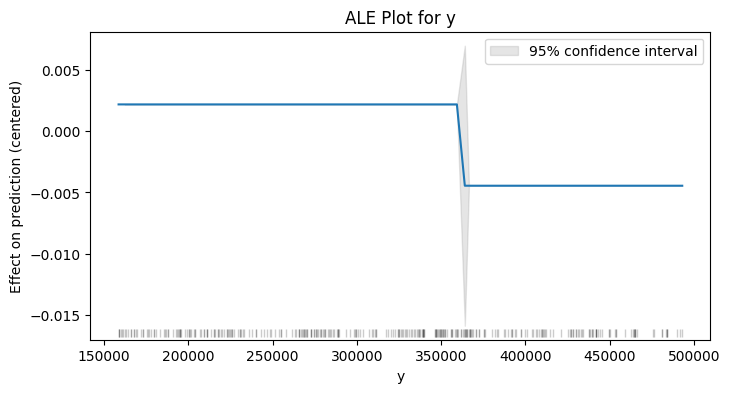

In [18]:
try:
    model
    X_train
except NameError:
    raise NameError("Required variables not defined.")
all_features = X_train.columns.tolist()
focus_feature = 'Unemployment Rate'
if focus_feature not in all_features:
    print(f"Error: Focus feature '{focus_feature}' not found in X_train columns: {all_features}")
else:
    other_features = [f for f in all_features if f != focus_feature]
    num_random_features = 2
    actual_num_random = min(num_random_features, len(other_features))
    if actual_num_random > 0:
        random_features = random.sample(other_features, actual_num_random)
    else:
        random_features = []
    features_to_plot = [focus_feature] + random_features
    for feature in features_to_plot:
        try:
            ale_eff = ale(
                X=X_train,
                model=model,
                feature=[feature],
                grid_size=50,
                include_CI=True,
                C=0.95
            )
            plt.title(f'ALE Plot for {feature}')
            plt.show()
        except Exception as e:
            print(f"Error generating ALE plot for {feature}: {e}")

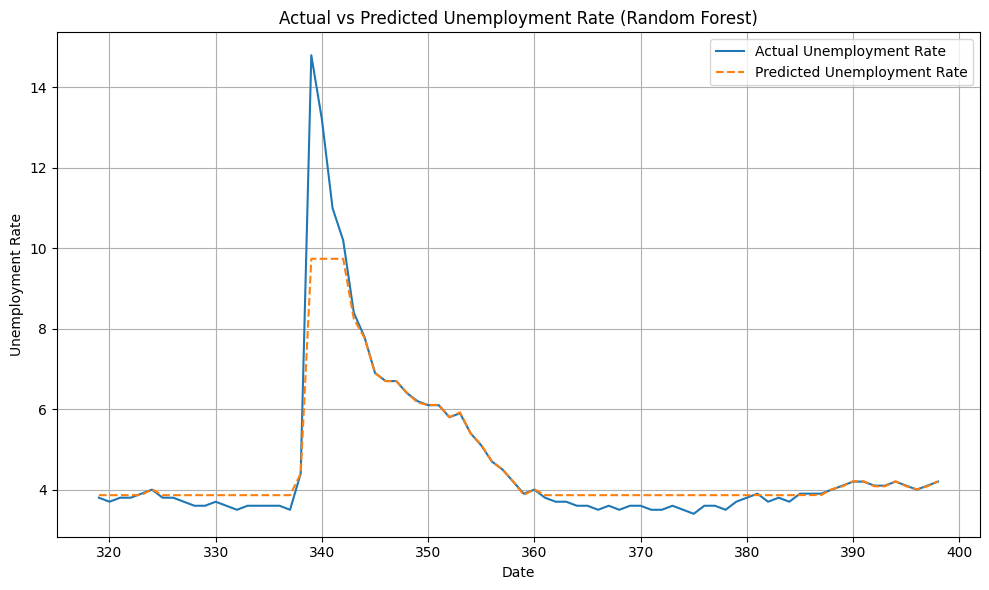

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(y_test.index, y_test.values, label='Actual Unemployment Rate')
plt.plot(y_test.index, y_pred, label='Predicted Unemployment Rate', linestyle='--')
plt.title('Actual vs Predicted Unemployment Rate (Random Forest)')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

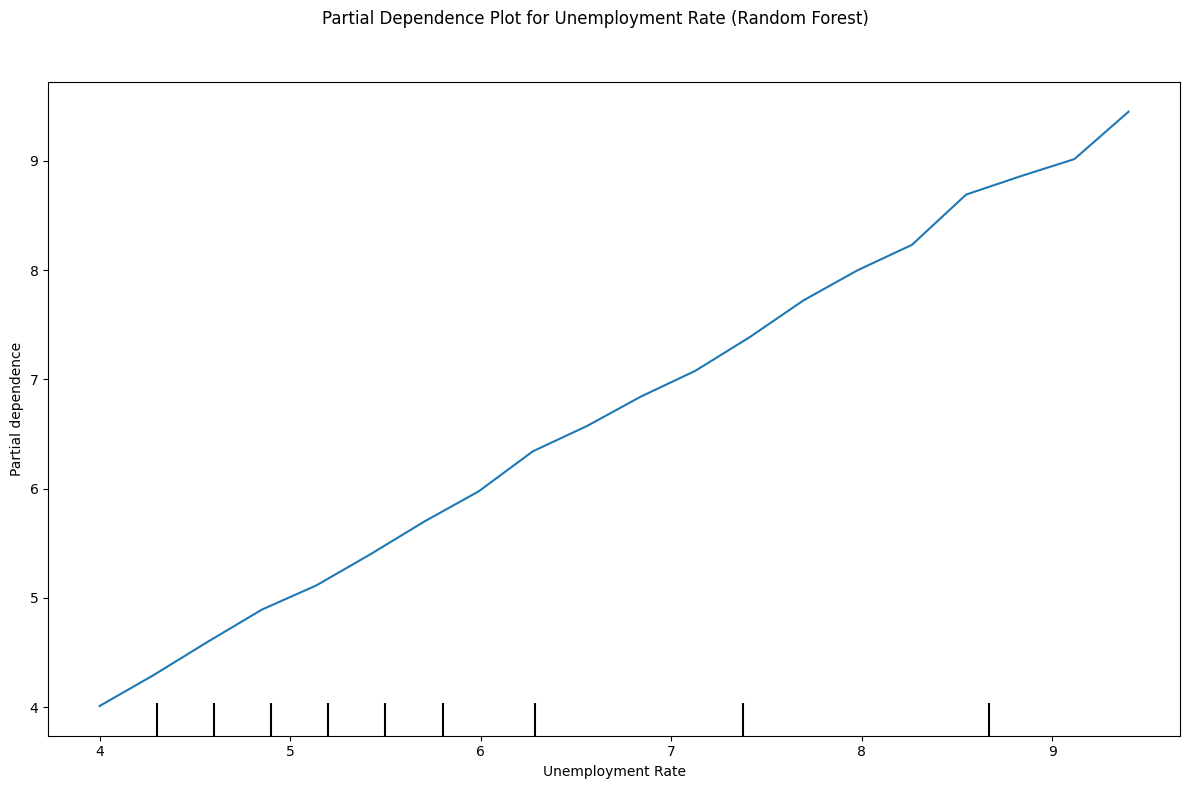

In [20]:
from sklearn.inspection import PartialDependenceDisplay

pdp_features = ['Unemployment Rate']

pdp_features = [f for f in pdp_features if f in X_train.columns]

if pdp_features:
    try:
        fig, ax = plt.subplots(figsize=(12, 8))
        display = PartialDependenceDisplay.from_estimator(
            model,
            X_train,
            pdp_features,
            kind='average',
            ax=ax,
            n_jobs=-1,
            grid_resolution=20
        )
        fig.suptitle('Partial Dependence Plot for Unemployment Rate (Random Forest)')
        plt.subplots_adjust(top=0.9)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show(fig)
    except Exception as e:
        print(f"Could not generate PDP plot: {e}")
else:
    print("Skipping PDP plot as selected feature is not available.")

  0%|          | 0/399 [00:00<?, ?it/s]

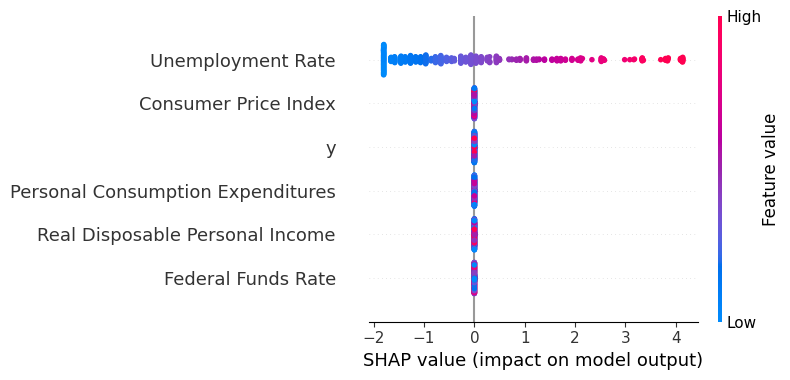

In [21]:
import shap
import pandas as pd
feature_cols = X.columns.tolist()
X_shap = X
explainer = shap.KernelExplainer(lambda X: model.predict(pd.DataFrame(X, columns=feature_cols)), X_shap)
shap_values = explainer.shap_values(X_shap)
shap.summary_plot(shap_values, X_shap)

  0%|          | 0/1 [00:00<?, ?it/s]

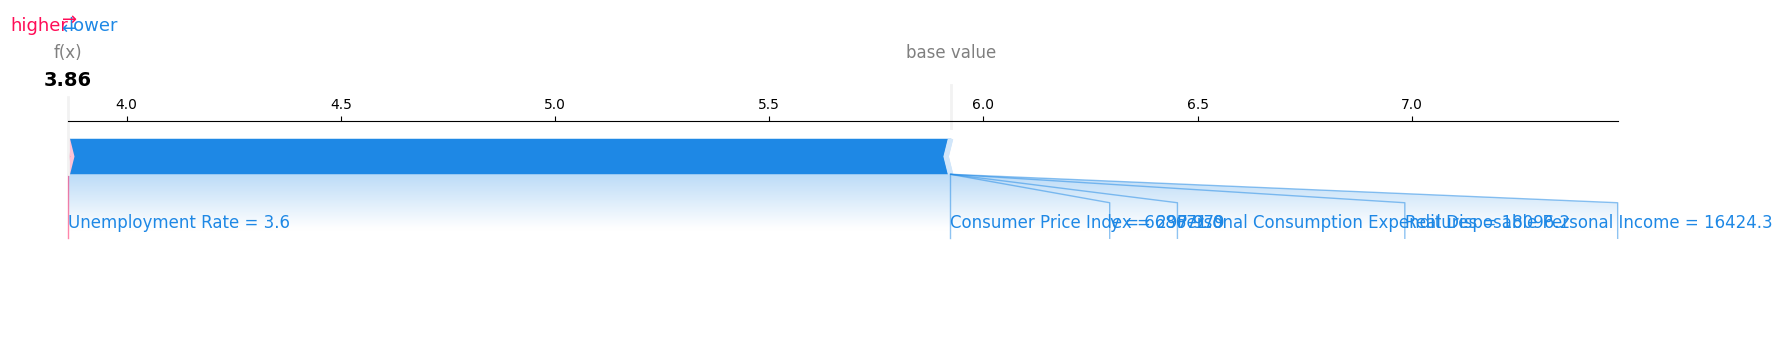

In [22]:
import shap
import pandas as pd
import numpy as np
i = 50
instance = X_test.iloc[[i]]
explainer = shap.KernelExplainer(model.predict, X_train)
shap_values = explainer.shap_values(instance)

shap.force_plot(explainer.expected_value, shap_values[0], instance.iloc[0], matplotlib=True)

In [25]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns.tolist(),
    class_names=[str(c) for c in np.unique(y)],
    mode='regression'
)

sample_idx = 0
sample = X_test.iloc[sample_idx].values
exp = explainer.explain_instance(sample, model.predict, num_features=10)

exp.show_in_notebook(show_table=True, show_all=False)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
